# Linear Mixed Models (LMM)

In this example we will learn how to use LMM to develop soil-specific calibration curves for a hypothetical soil moisture sensor. We will compare a traditional linear model with fixed intercept and slope (one model for all soils) versus the use of a random intercept and slope to better account for the effects of soil texture. The LMM extends a standard linear model by allowing some parameters to vary across groups or experimental units. This is useful when dealing with grouped data, which can occur in agronomy when data are collected across different locations, years, or soil types.

The dataset consists of `Voltage` in mV as the independent variable, `Moisture` in % as the dependent variable, and three different soils (Sand, Loam, and Clay). There are 25 observations per soil texture.



## **Standard linear model with fixed effects only**
Let’s consider a typical linear regression method:

$$ y = \beta_0 + \beta_1 x + \varepsilon $$


where:
- $y$ is the response variable (e.g., soil moisture content from a sensor)
- $x$ is a predictor variable (e.g., voltage output from the sensor)
- $\varepsilon$ is the residual error, assumed to be normally distributed


#### Linear mixed effects model (LMM) with **random effects** (intercept only) in addition to the fixed effects.

An LMM of this type can be written as:

$$ y_{ij} = \beta_0 + b_j + \beta_1 x_{ij} + \varepsilon_{ij}$$

where:
- $i$ indexes individual observations,
- $j$ indexes groups (e.g., different farms or sensors),
- $b_j$ is a **random intercept** that allows each group to have its own baseline response,
- $\varepsilon_{ij}$ is the residual error.

In this case, $b_j \sim N(0, \sigma_b^2)$, meaning each farm (or sensor) has a different intercept drawn from a normal distribution.

A more complex LMM could also allow slopes to vary across groups:

$$ y_{ij} = (\beta_0 + b_{0j}) + (\beta_1 + b_{1j}) x_{ij} + \varepsilon_{ij} $$

where both the **intercept** ($b_{0j}$) and **slope** ($b_{1j}$) are random effects.


In [1]:
# Import modules
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.formula.api as sm
import statsmodels.formula.api as smf

In [2]:
# Raw dataset
data ={'Voltage': [1500, 1583, 1666, 1750, 1833, 1916, 2000, 2083, 2166, 2250, 2333, 2416, 2500, 2583, 2666, 2750, 2833, 2916, 3000, 3083, 3166, 3250, 3333, 3416, 3500,
                   1500, 1583, 1666, 1750, 1833, 1916, 2000, 2083, 2166, 2250, 2333, 2416, 2500, 2583, 2666, 2750, 2833, 2916, 3000, 3083, 3166, 3250, 3333, 3416, 3500,
                   1500, 1583, 1666, 1750, 1833, 1916, 2000, 2083, 2166, 2250, 2333, 2416, 2500, 2583, 2666, 2750, 2833, 2916, 3000, 3083, 3166, 3250, 3333, 3416, 3500],
       'Soil': ['Sand', 'Sand', 'Sand', 'Sand', 'Sand', 'Sand', 'Sand', 'Sand', 'Sand', 'Sand', 'Sand', 'Sand', 'Sand', 'Sand', 'Sand', 'Sand', 'Sand', 'Sand', 'Sand', 'Sand', 'Sand', 'Sand', 'Sand', 'Sand', 'Sand',
                'Loam', 'Loam', 'Loam', 'Loam', 'Loam', 'Loam', 'Loam', 'Loam', 'Loam', 'Loam', 'Loam', 'Loam', 'Loam', 'Loam', 'Loam', 'Loam', 'Loam', 'Loam', 'Loam', 'Loam', 'Loam', 'Loam', 'Loam', 'Loam', 'Loam', 
                'Clay', 'Clay', 'Clay', 'Clay', 'Clay', 'Clay', 'Clay', 'Clay', 'Clay', 'Clay', 'Clay', 'Clay', 'Clay', 'Clay', 'Clay', 'Clay', 'Clay', 'Clay', 'Clay', 'Clay', 'Clay', 'Clay', 'Clay', 'Clay', 'Clay'],
       'Moisture': [11.6, 11.1, 13.5, 16.2, 13.3, 14.1, 18.8, 17.9, 16.1, 19.0, 17.7, 18.6, 20.9, 17.1, 18.4, 21.6, 21.5, 25.1, 23.4, 23.1, 30.0, 27.3, 28.7, 26.4, 29.0,
                    15.4, 15.1, 18.0, 18.0, 19.5, 20.3, 24.3, 23.3, 23.2, 26.5, 25.3, 28.1, 26.8, 28.6, 31.5, 33.3, 33.8, 34.6, 35.5, 35.3, 37.3, 38.8, 41.7, 42.0, 40.7,
                    18.9, 19.5, 20.6, 23.7, 25.8, 27.2, 26.4, 28.6, 30.9, 33.2, 32.8, 34.7, 35.0, 36.4, 40.5, 42.7, 42.4, 45.3, 45.9, 46.1, 48.9, 52.0, 51.4, 55.0, 51.1]}

In [32]:
# Convert dictionary to Pandas Dataframe
df = pd.DataFrame(data)
df.head()


,Voltage,Soil,Moisture
0,1500,Sand,11.6
1,1583,Sand,11.1
2,1666,Sand,13.5
3,1750,Sand,16.2
4,1833,Sand,13.3


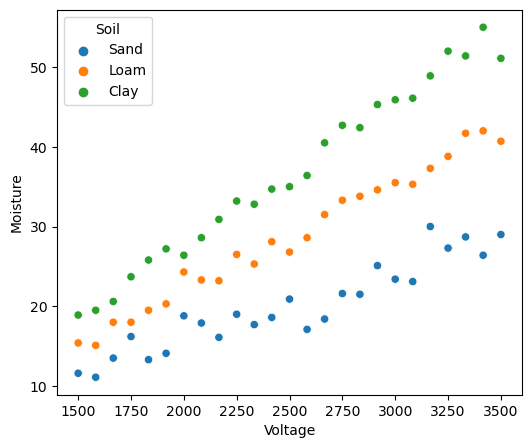

In [33]:
# Inspect dataset
plt.figure(figsize=(6,5))
sns.scatterplot(data=df, x='Voltage', y='Moisture', hue='Soil');

#### Standard linear model with fixed effects 

In [34]:
# Fit Standard Linear Model (ignores soil type)
lm = smf.ols("Moisture ~ Voltage", data=df).fit()
print(lm.summary())


                            OLS Regression Results                            
Dep. Variable:               Moisture   R-squared:                       0.547
Model:                            OLS   Adj. R-squared:                  0.541
Method:                 Least Squares   F-statistic:                     88.12
Date:                Wed, 02 Apr 2025   Prob (F-statistic):           3.51e-14
Time:                        16:59:49   Log-Likelihood:                -255.51
No. Observations:                  75   AIC:                             515.0
Df Residuals:                      73   BIC:                             519.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -4.9333      3.655     -1.350      0.1

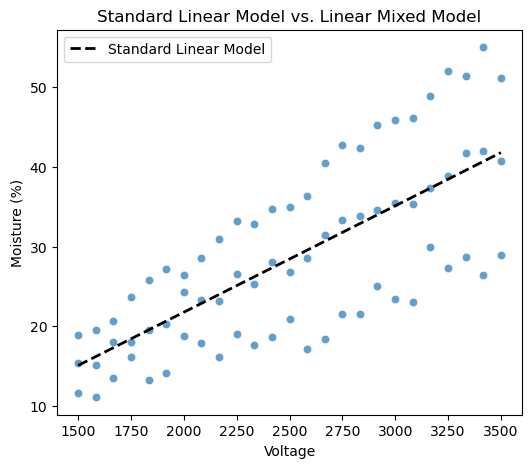

In [35]:
# Plot the observed data with the standard linear model
plt.figure(figsize=(6, 5))
sns.scatterplot(data=df, x="Voltage", y="Moisture", alpha=0.7)

x_vals = np.linspace(1500, 3500, 100)
y_vals = lm.params["Intercept"] + lm.params["Voltage"] * x_vals
plt.plot(x_vals, y_vals, 'k--', label="Standard Linear Model", linewidth=2)
plt.xlabel("Voltage")
plt.ylabel("Moisture (%)")
plt.legend()
plt.title("Standard Linear Model vs. Linear Mixed Model")
plt.show()

It is evident that this general model with a fixed intercept and slope for all groups captures the main trend, but does not represent two out of three groups. This goodness of fit is not ideal for making field predictions using this model. An alternative analysis using linear mixed effects that considers intercepts and/or slopes for each soil type is recommended.

#### Linear model with mixed effects (only intercept)

In [36]:
# Fit LMM to account for different soil types (random intercept only, the slope is constant)
lmm = smf.mixedlm("Moisture ~ Voltage", data=df, groups=df['Soil']).fit()
print(lmm.summary())


         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: Moisture 
No. Observations: 75      Method:             REML     
No. Groups:       3       Scale:              7.8406   
Min. group size:  25      Log-Likelihood:     -194.8542
Max. group size:  25      Converged:          Yes      
Mean group size:  25.0                                 
-------------------------------------------------------
            Coef.  Std.Err.   z    P>|z|  [0.025 0.975]
-------------------------------------------------------
Intercept   -4.933    4.974 -0.992 0.321 -14.682  4.816
Voltage      0.013    0.001 24.806 0.000   0.012  0.014
Group Var   68.485   24.913                            



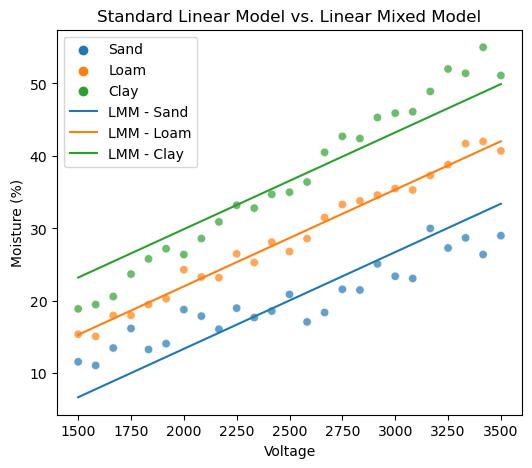

In [37]:
# Plot the observed data LMM regression lines (separate per soil type, random intercept and constant slope)
plt.figure(figsize=(6, 5))
sns.scatterplot(data=df, x="Voltage", y="Moisture", hue="Soil", alpha=0.7)

x_vals = np.linspace(1500, 3500, 100)
for soil in df['Soil'].unique():
    idx_soil = df["Soil"] == soil
    soil_subset = df[idx_soil]
    b0j = lmm.random_effects[soil].iloc[0]  # Extract random effects for this soil type
    y_vals = (lmm.fe_params["Intercept"] + b0j) + lmm.fe_params["Voltage"] * x_vals # fe_params are for the fixed effect
  
    plt.plot(x_vals, y_vals, label=f"LMM - {soil}")

plt.xlabel("Voltage")
plt.ylabel("Moisture (%)")
plt.legend()
plt.title("Standard Linear Model vs. Linear Mixed Model")
plt.show()

#### Linear model with mixed effects (intercept and slope)

In [38]:
# Fit LMM to account for different soil types (random intercept and slope)
lmm_ris = smf.mixedlm("Moisture ~ Voltage", data=df, groups=df['Soil'], re_formula="~Voltage").fit()
print(lmm_ris.summary())


             Mixed Linear Model Regression Results
Model:                MixedLM   Dependent Variable:   Moisture 
No. Observations:     75        Method:               REML     
No. Groups:           3         Scale:                2.0592   
Min. group size:      25        Log-Likelihood:       -161.3161
Max. group size:      25        Converged:            Yes      
Mean group size:      25.0                                     
---------------------------------------------------------------
                    Coef.  Std.Err.   z    P>|z|  [0.025 0.975]
---------------------------------------------------------------
Intercept           -4.933    2.634 -1.873 0.061 -10.095  0.229
Voltage              0.013    0.530  0.025 0.980  -1.025  1.051
Group Var           19.303   29.713                            
Group x Voltage Cov -0.040                                     
Voltage Var          0.842                                     



C:\Users\andrespatrignani\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\andrespatrignani\anaconda3\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2201: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
C:\Users\andrespatrignani\anaconda3\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2262: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)


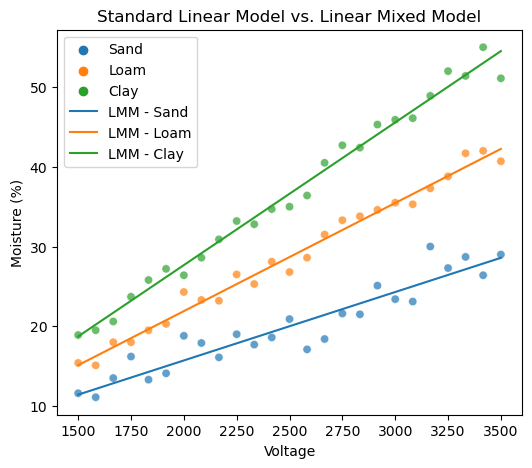

In [39]:
# Plot the observed data
plt.figure(figsize=(6, 5))
sns.scatterplot(data=df, x="Voltage", y="Moisture", hue="Soil", alpha=0.7)

x_vals = np.linspace(1500, 3500, 100)
# Plot LMM regression lines (separate per soil type)
for soil in df['Soil'].unique():
    idx_soil = df["Soil"] == soil
    soil_subset = df[idx_soil]
    b0j, b1j = lmm_ris.random_effects[soil]  # Extract random effects for this soil type
    y_vals = (lmm_ris.fe_params["Intercept"] + b0j) + (lmm_ris.fe_params["Voltage"] + b1j) * x_vals
  
    plt.plot(x_vals, y_vals, label=f"LMM - {soil}")

plt.xlabel("Voltage")
plt.ylabel("Moisture (%)")
plt.legend()
plt.title("Standard Linear Model vs. Linear Mixed Model")
plt.show()